In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 — Extract Frames from Video & Prepare COLMAP Workspace

### Objective
Extract a representative set of frames from an input video and prepare a clean, COLMAP-compatible workspace for 3D reconstruction and Gaussian Splatting training.

### Description
This step performs the following actions:
- Automatically creates a new `COLMAP_WORKSPACE`.
  - If the base workspace already exists, a suffix (`_1`, `_2`, …) is added to avoid overwriting previous runs.
- Uniformly samples `NUM_FRAMES` frames across the full duration of the video.
- Saves extracted frames into an `images/` directory following COLMAP conventions.
- Displays a sample frame to visually verify image quality and correctness.

### Inputs
- **Video path**: `VIDEO_PATH`
- **Number of extracted frames**: `NUM_FRAMES`

In [ ]:
!pip install opencv-python

In [ ]:
VIDEO_PATH = "/content/drive/MyDrive/thesis/video/video-8.MOV"

In [ ]:
import cv2
import os

import numpy as np
from tqdm import tqdm

In [ ]:
import os

BASE_WORKSPACE_DIR = "/content/drive/MyDrive/thesis/colmap_workspace"
NUM_FRAMES = 200
IMG_EXT = ".png"

def get_next_available_workspace(base_dir):
    if not os.path.exists(base_dir):
        return base_dir

    idx = 1
    while True:
        candidate = f"{base_dir}_{idx}"
        if not os.path.exists(candidate):
            return candidate
        idx += 1

COLMAP_WORKSPACE = get_next_available_workspace(BASE_WORKSPACE_DIR)
os.makedirs(COLMAP_WORKSPACE, exist_ok=True)

INPUT_IMAGES_DIR = os.path.join(COLMAP_WORKSPACE, "images")
os.makedirs(INPUT_IMAGES_DIR, exist_ok=True)

print("Using COLMAP_WORKSPACE:", COLMAP_WORKSPACE)
print("Using INPUT_IMAGES_DIR:", INPUT_IMAGES_DIR)


Using COLMAP_WORKSPACE: /content/drive/MyDrive/thesis/colmap_workspace_6
Using INPUT_IMAGES_DIR: /content/drive/MyDrive/thesis/colmap_workspace_6/images


In [ ]:
cap = cv2.VideoCapture(VIDEO_PATH)

assert cap.isOpened(), "❌ Cannot open video"

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
duration = total_frames / fps

print(f"Total frames: {total_frames}")
print(f"FPS: {fps}")
print(f"Duration: {duration:.2f}s")

frame_indices = np.linspace(
    0, total_frames - 1, NUM_FRAMES, dtype=int
)

Total frames: 3571
FPS: 29.999159922712888
Duration: 119.04s


In [ ]:
saved = 0
frame_id = 0

pbar = tqdm(total=NUM_FRAMES)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if frame_id in frame_indices:
        fname = f"frame_{saved:04d}{IMG_EXT}"
        fpath = os.path.join(INPUT_IMAGES_DIR, fname)

        cv2.imwrite(fpath, frame)

        saved += 1
        pbar.update(1)

        if saved >= NUM_FRAMES:
            break

    frame_id += 1

cap.release()
pbar.close()

print(f"✅ Saved {saved} frames to:")
print(INPUT_IMAGES_DIR)

100%|██████████| 200/200 [01:55<00:00,  1.73it/s]

✅ Saved 200 frames to:
/content/drive/MyDrive/thesis/colmap_workspace_6/images


(np.float64(-0.5), np.float64(1079.5), np.float64(1919.5), np.float64(-0.5))

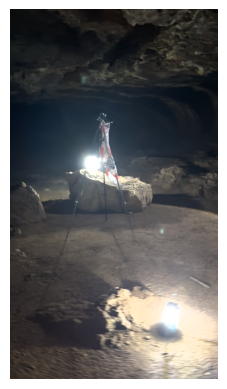

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

imgs = sorted(os.listdir(INPUT_IMAGES_DIR))
sample = Image.open(os.path.join(INPUT_IMAGES_DIR, imgs[len(imgs)//2]))

plt.imshow(sample)
plt.axis("off")

## Step 2 — Run COLMAP: Feature Extraction, Matching & Sparse Reconstruction

### Objective
Reconstruct a sparse 3D scene from the extracted images using COLMAP.  
This step computes camera poses, sparse point clouds, and camera intrinsics required for Gaussian Splatting training.

### Description
This step performs a full COLMAP pipeline in **headless mode** (no GUI), suitable for Google Colab:

- Installs COLMAP inside the Colab environment.
- Sets environment variables for:
  - Input images
  - COLMAP database
  - Sparse reconstruction output
- Disables Qt GUI and GPU usage to ensure stability in Colab.
- Runs the following COLMAP stages:
  1. **Feature Extraction** (SIFT features per image)
  2. **Exhaustive Matching** (pairwise feature matching)
  3. **Mapping** (sparse 3D reconstruction and camera pose estimation)

### Key Settings
- `SIMPLE_PINHOLE` camera model
- Single shared camera intrinsics (`single_camera = 1`)
- CPU-based SIFT extraction and matching
- Limited CPU threading for stability (`num_threads = 2`)

### Inputs
- Images directory: `COLMAP_WORKSPACE/images`
- COLMAP database: `COLMAP_WORKSPACE/database.db`

In [ ]:
!apt-get update -qq
!apt-get install -y colmap

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libamd2 libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libcamd2 libccolamd2 libceres2
  libcholmod3 libcolamd2 libcxsparse3 libdouble-conversion3 libevdev2
  libfreeimage3 libgflags2.2 libglew2.2 libgoogle-glog0v5 libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libilmbase25 libinput-bin
  libinput10 libjxr0 libmd4c0 libmetis5 libmtdev1 libopenexr25 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libraw20
  librsvg2-common libspqr2 libsuitesparseconfig5 libwacom-bin libwacom-common
  libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1 libxcb-render-util0
  l

In [ ]:
!colmap --help


COLMAP 3.7 -- Structure-from-Motion and Multi-View Stereo
              (Commit Unknown on Unknown without CUDA)

Usage:
  colmap [command] [options]

Documentation:
  https://colmap.github.io/

Example usage:
  colmap help [ -h, --help ]
  colmap gui
  colmap gui -h [ --help ]
  colmap automatic_reconstructor -h [ --help ]
  colmap automatic_reconstructor --image_path IMAGES --workspace_path WORKSPACE
  colmap feature_extractor --image_path IMAGES --database_path DATABASE
  colmap exhaustive_matcher --database_path DATABASE
  colmap mapper --image_path IMAGES --database_path DATABASE --output_path MODEL
  ...

Available commands:
  help
  gui
  automatic_reconstructor
  bundle_adjuster
  color_extractor
  database_cleaner
  database_creator
  database_merger
  delaunay_mesher
  exhaustive_matcher
  feature_extractor
  feature_importer
  hierarchical_mapper
  image_deleter
  image_filterer
  image_rectifier
  image_registrator
  image_undistorter
  image_undistorter_standalone
  mapper

In [ ]:
import os

os.environ["IMAGE_PATH"] = INPUT_IMAGES_DIR
os.environ["DB_PATH"] = os.path.join(COLMAP_WORKSPACE, "database.db")
os.environ["SPARSE_PATH"] = os.path.join(COLMAP_WORKSPACE, "sparse")
os.makedirs(os.environ["SPARSE_PATH"], exist_ok=True)

os.environ["QT_QPA_PLATFORM"] = "offscreen"



In [ ]:
!colmap feature_extractor \
  --database_path "$DB_PATH" \
  --image_path "$IMAGE_PATH" \
  --ImageReader.single_camera 1 \
  --ImageReader.camera_model SIMPLE_PINHOLE \
  --SiftExtraction.use_gpu 0 \
  --SiftExtraction.num_threads 2



Feature extraction

Processed file [1/200]
  Name:            frame_0001.png
  Dimensions:      1080 x 1920
  Camera:          #2 - SIMPLE_PINHOLE
  Focal Length:    2304.00px
  Features:        11067
Processed file [2/200]
  Name:            frame_0000.png
  Dimensions:      1080 x 1920
  Camera:          #2 - SIMPLE_PINHOLE
  Focal Length:    2304.00px
  Features:        15217
Processed file [3/200]
  Name:            frame_0003.png
  Dimensions:      1080 x 1920
  Camera:          #2 - SIMPLE_PINHOLE
  Focal Length:    2304.00px
  Features:        6306
Processed file [4/200]
  Name:            frame_0002.png
  Dimensions:      1080 x 1920
  Camera:          #2 - SIMPLE_PINHOLE
  Focal Length:    2304.00px
  Features:        11544
Processed file [5/200]
  Name:            frame_0004.png
  Dimensions:      1080 x 1920
  Camera:          #2 - SIMPLE_PINHOLE
  Focal Length:    2304.00px
  Features:        6569
Processed file [6/200]
  Name:            frame_0005.png
  Dimensions:      

In [ ]:
!colmap exhaustive_matcher \
  --database_path "$DB_PATH" \
  --SiftMatching.use_gpu 0



Exhaustive feature matching

Matching block [1/4, 1/4] in 130.472s
Matching block [1/4, 2/4] in 131.247s
Matching block [1/4, 3/4] in 134.108s
Matching block [1/4, 4/4] in 137.967s
Matching block [2/4, 1/4] in 139.294s
Matching block [2/4, 2/4] in 132.783s
Matching block [2/4, 3/4] in 134.187s
Matching block [2/4, 4/4] in 141.271s
Matching block [3/4, 1/4] in 140.313s
Matching block [3/4, 2/4] in 141.373s
Matching block [3/4, 3/4] in 137.078s
Matching block [3/4, 4/4] in 142.427s
Matching block [4/4, 1/4] in 132.216s
Matching block [4/4, 2/4] in 131.814s
Matching block [4/4, 3/4] in 135.663s
Matching block [4/4, 4/4] in 135.889s
Elapsed time: 36.324 [minutes]


In [ ]:
!colmap mapper \
  --database_path "$DB_PATH" \
  --image_path "$IMAGE_PATH" \
  --output_path "$SPARSE_PATH"


Streaming output truncated to the last 5000 lines.
   3  1.345097e+05    1.17e+00    1.75e+02   3.54e-01   9.98e-01  2.70e+05        1    4.38e-01    2.35e+00
   4  1.345097e+05    4.13e-02    1.08e+01   6.58e-02   1.00e+00  8.10e+05        1    3.73e-01    2.73e+00
   5  1.345097e+05    4.29e-04    1.07e+00   7.51e-03   1.00e+00  2.43e+06        1    3.60e-01    3.09e+00
   6  1.345097e+05    2.02e-06    3.85e-02   6.55e-04   1.00e+00  7.29e+06        1    3.81e-01    3.47e+00


Bundle adjustment report
------------------------
    Residuals : 379880
   Parameters : 96798
   Iterations : 7
         Time : 3.48581 [s]
 Initial cost : 0.595791 [px]
   Final cost : 0.59505 [px]
  Termination : Convergence

  => Completed observations: 16
  => Merged observations: 30
  => Filtered observations: 6
  => Changed observations: 0.000274
  => Filtered images: 0

Registering image #163 (112)

  => Image sees 935 / 2933 points

Pose refinement report
----------------------
    Residuals : 1884
  

## Step 3 — Train 3D Gaussian Splatting Model

### Objective
Train a 3D Gaussian Splatting model using the sparse reconstruction produced by COLMAP, generating a high-quality neural scene representation suitable for real-time rendering.

### Description
This step performs the following actions:

- Automatically creates a new output directory for Gaussian Splatting results.
  - If the base output directory already exists, a suffix (`_1`, `_2`, …) is appended to prevent overwriting previous runs.
- Clones the official **Gaussian Splatting** repository with all required submodules.
- Installs all required Python dependencies and custom CUDA extensions.
- Launches the Gaussian Splatting training process using the COLMAP workspace as input.

### Inputs
- COLMAP workspace containing:

1.   images/
2.   sparse/0/





In [ ]:
import os

BASE_OUTPUT_PATH = "/content/drive/MyDrive/thesis/output"

def get_next_available_dir(base_dir):
    if not os.path.exists(base_dir):
        return base_dir

    idx = 1
    while True:
        candidate = f"{base_dir}_{idx}"
        if not os.path.exists(candidate):
            return candidate
        idx += 1

OUTPUT_PATH = get_next_available_dir(BASE_OUTPUT_PATH)
os.makedirs(OUTPUT_PATH, exist_ok=True)

os.environ["OUTPUT_PATH"] = OUTPUT_PATH

print("Using OUTPUT_PATH:", OUTPUT_PATH)


Using OUTPUT_PATH: /content/drive/MyDrive/thesis/output_6


In [ ]:
import shutil
import os

GS_DIR = "gaussian-splatting"

if os.path.exists(GS_DIR):
    shutil.rmtree(GS_DIR)
    print("✅ Removed existing gaussian-splatting folder")
else:
    print("ℹ️ gaussian-splatting folder does not exist")

!git clone --recursive https://github.com/graphdeco-inria/gaussian-splatting

ℹ️ gaussian-splatting folder does not exist
Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 1053, done.
remote: Total 1053 (delta 0), reused 0 (delta 0), pack-reused 1053 (from 1)
Receiving objects: 100% (1053/1053), 78.71 MiB | 34.33 MiB/s, done.
Resolving deltas: 100% (593/593), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.  

In [ ]:
%cd gaussian-splatting

!pip install plyfile tqdm imageio opencv-python pyvista trimesh
!pip install submodules/diff-gaussian-rasterization
!pip install submodules/simple-knn

%cd ..

/content/gaussian-splatting
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.5/740.5 kB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 MB 17.8 MB/s eta 0:00:00
Processing ./submodules/diff-gaussian-rasterization
  Preparing metadata (setup.py) ... done
  Created wheel for diff_gaussian_rasterization: filename=diff_gaussian_rasterization-0.0.0-cp312-cp312-linux_x86_64.whl size=3809019 sha256=31c51dff6888b5f3f1b48bf90175deedbdf8cfae15d29b003d46d1205216e8f8
  Stored in directory: /root/.cache/pip/wheels/01/e0/e8/f40a1cd6a1d5760cbd3036081bdad5b36c41fc11c786d4a404
Successfully built diff_gaussian_rasterization
Processing ./submodules/simple-knn
  Preparing metadata (setup.py) ... done
  Created wheel for simple_knn: filename=si

In [ ]:
%cd /content/gaussian-splatting

!python train.py \
  -s "$COLMAP_WORKSPACE" \
  -m "$OUTPUT_PATH" \
  --iterations 30000 \
  -r 2 \
  --eval


/content/gaussian-splatting
2026-03-18 06:17:36.512043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-18 06:17:36.530667: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773814656.553238  104040 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773814656.560742  104040 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773814656.579928  104040 computation_placer.cc:177] computation placer already registered. Please chec